<h1></h1>

<h1>Initialization</h1>

In [1001]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

<h1>Data Collection</h1>

In [1002]:
df = pd.read_csv(filepath_or_buffer="./Titanic-Dataset.csv")

<h1>EDA</h1>

In [1003]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [1004]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [1005]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [1006]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

<h1>PreProcessing</h1>

In [1007]:
df["Age"] = df.groupby(["Pclass", "Sex"])["Age"].transform(
    lambda age: age.fillna(age.median())
)
df["Age"].isna().sum()

0

In [1008]:
df = df.drop(axis=1, columns="PassengerId")
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.5,1,2,W./C. 6607,23.4500,NaN,S
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [1009]:
df["Has_Cabin"] = df["Cabin"].notna().astype(int)
df["Deck"] = df["Cabin"].str[0].fillna("Unknown")
df = df.drop(axis=1, columns="Cabin")
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin,Deck
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0,Unknown
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,Unknown
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,C
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,0,Unknown
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,1,B
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.5,1,2,W./C. 6607,23.4500,S,0,Unknown
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,1,C


In [1010]:
Deck_items = pd.get_dummies(df["Deck"], drop_first=True).astype(int)
df = pd.concat([df, Deck_items], axis=1)
df = df.drop(axis=1, columns="Deck")
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin,B,C,D,E,F,G,T,Unknown
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0,0,0,0,0,0,0,0,1
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,0,1,0,0,0,0,0,0
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,0,0,0,0,0,0,0,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,0,1,0,0,0,0,0,0
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,0,0,0,0,0,0,0,0,1
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,1,1,0,0,0,0,0,0,0
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.5,1,2,W./C. 6607,23.4500,S,0,0,0,0,0,0,0,0,1
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,1,0,1,0,0,0,0,0,0


In [1011]:
sex_items = pd.get_dummies(df["Sex"], drop_first=True).astype(int)
df = pd.concat([df, sex_items], axis=1)
df = df.drop(axis=1, columns="Sex")
df

,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin,B,C,D,E,F,G,T,Unknown,male
0,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,S,0,0,0,0,0,0,0,0,1,1
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C,1,0,1,0,0,0,0,0,0,0
2,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,S,0,0,0,0,0,0,0,0,1,0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,S,1,0,1,0,0,0,0,0,0,0
4,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,S,0,0,0,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",27.0,0,0,211536,13.0000,S,0,0,0,0,0,0,0,0,1,1
887,1,1,"Graham, Miss. Margaret Edith",19.0,0,0,112053,30.0000,S,1,1,0,0,0,0,0,0,0,0
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",21.5,1,2,W./C. 6607,23.4500,S,0,0,0,0,0,0,0,0,1,0
889,1,1,"Behr, Mr. Karl Howell",26.0,0,0,111369,30.0000,C,1,0,1,0,0,0,0,0,0,1


In [1012]:
embarked_items = pd.get_dummies(df["Embarked"], drop_first=True).astype(int)
df = pd.concat([df, embarked_items], axis=1)
df = df.drop(axis=1, columns="Embarked")
df

,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Has_Cabin,B,C,D,E,F,G,T,Unknown,male,Q,S
0,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,0,0,0,0,0,0,0,0,1,1,0,1
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,1,0,1,0,0,0,0,0,0,0,0,0
2,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,0,0,0,0,0,0,0,0,1,0,0,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,1,0,1,0,0,0,0,0,0,0,0,1
4,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,0,0,0,0,0,0,0,0,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",27.0,0,0,211536,13.0000,0,0,0,0,0,0,0,0,1,1,0,1
887,1,1,"Graham, Miss. Margaret Edith",19.0,0,0,112053,30.0000,1,1,0,0,0,0,0,0,0,0,0,1
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",21.5,1,2,W./C. 6607,23.4500,0,0,0,0,0,0,0,0,1,0,0,1
889,1,1,"Behr, Mr. Karl Howell",26.0,0,0,111369,30.0000,1,0,1,0,0,0,0,0,0,1,0,0


In [1013]:
df["Family_Size"] = df["SibSp"] + df["Parch"] + 1
df["Is_Alone"] = (df["Family_Size"] == 1).astype(int)
df = df.drop(axis=1, columns=["Parch", "SibSp"])
df

,Survived,Pclass,Name,Age,Ticket,Fare,Has_Cabin,B,C,D,E,F,G,T,Unknown,male,Q,S,Family_Size,Is_Alone
0,0,3,"Braund, Mr. Owen Harris",22.0,A/5 21171,7.2500,0,0,0,0,0,0,0,0,1,1,0,1,2,0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,PC 17599,71.2833,1,0,1,0,0,0,0,0,0,0,0,0,2,0
2,1,3,"Heikkinen, Miss. Laina",26.0,STON/O2. 3101282,7.9250,0,0,0,0,0,0,0,0,1,0,0,1,1,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,113803,53.1000,1,0,1,0,0,0,0,0,0,0,0,1,2,0
4,0,3,"Allen, Mr. William Henry",35.0,373450,8.0500,0,0,0,0,0,0,0,0,1,1,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",27.0,211536,13.0000,0,0,0,0,0,0,0,0,1,1,0,1,1,1
887,1,1,"Graham, Miss. Margaret Edith",19.0,112053,30.0000,1,1,0,0,0,0,0,0,0,0,0,1,1,1
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",21.5,W./C. 6607,23.4500,0,0,0,0,0,0,0,0,1,0,0,1,4,0
889,1,1,"Behr, Mr. Karl Howell",26.0,111369,30.0000,1,0,1,0,0,0,0,0,0,1,0,0,1,1


<h1>Analyse</h1>

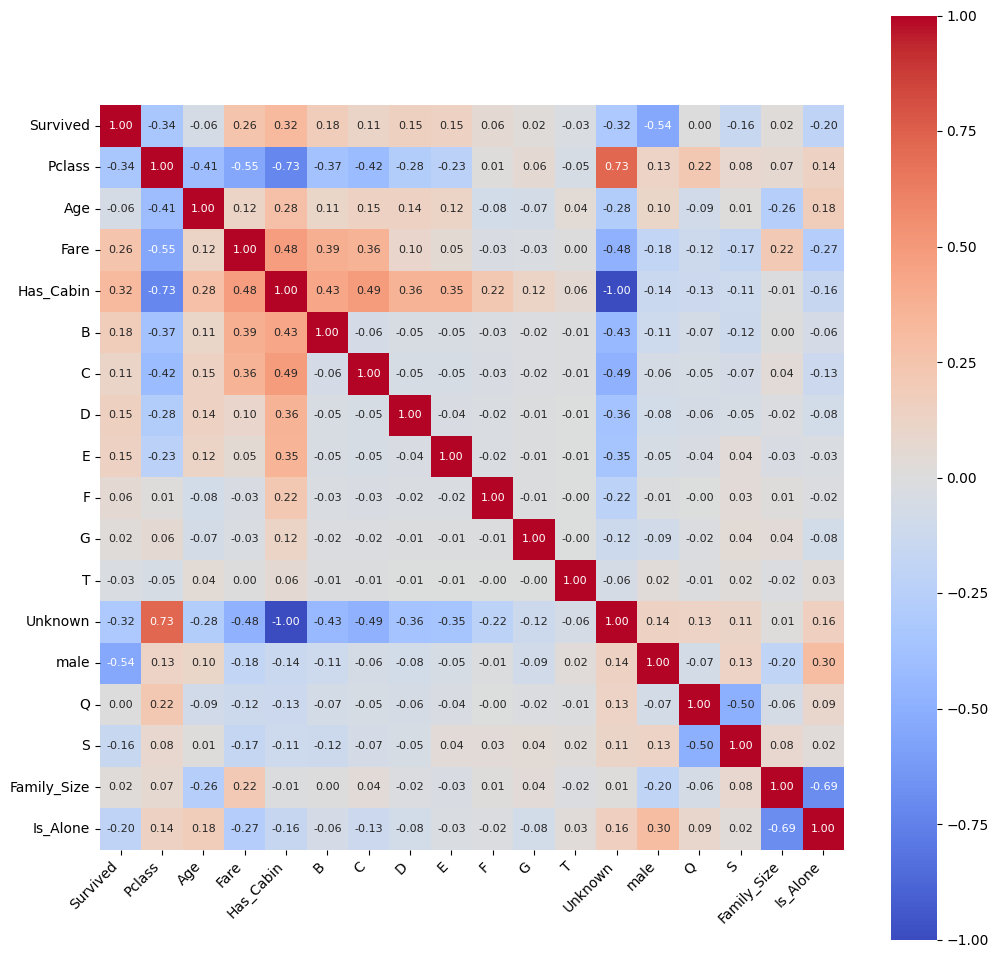

In [1014]:
correlated_df = df.drop(axis=1, columns=["Ticket", "Name"]).corr()

plt.figure(figsize=(12, 12))
sns.heatmap(correlated_df, cmap="coolwarm",
            annot=True, annot_kws={"size": 8},
            square=True, fmt="0.2f")
plt.xticks(rotation=45, ha="right")
plt.show()

<h1>Modeling</h1>

In [1015]:
x = df.drop(axis=1, columns=["Survived", "Name", "Ticket"])
y = df["Survived"]

In [1016]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.25)

model = LogisticRegression(max_iter=2525, C=0.1)
model.fit(x_train, y_train)

LogisticRegression(C=0.1, max_iter=2525)

In [1017]:
predicted_values = model.predict(x_test)

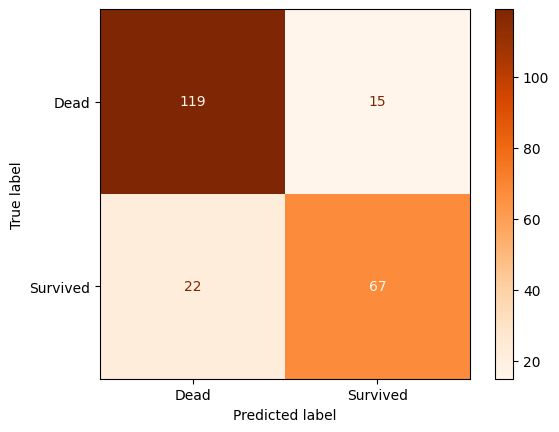

In [1018]:
cm = metrics.confusion_matrix(y_test, predicted_values)

disp = metrics.ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Dead", "Survived"]
)
disp.plot(cmap="Oranges")
plt.show()

In [1019]:
print(metrics.classification_report(y_test, predicted_values))
probs = model.predict_proba(x_test)[:, 1]
print(f"roc_auc= {metrics.roc_auc_score(y_test, probs)}")
print(f"Accuracy= {metrics.accuracy_score(y_test, predicted_values)}")

              precision    recall  f1-score   support

           0       0.84      0.89      0.87       134
           1       0.82      0.75      0.78        89

    accuracy                           0.83       223
   macro avg       0.83      0.82      0.82       223
weighted avg       0.83      0.83      0.83       223

roc_auc= 0.8809324165688411
Accuracy= 0.8340807174887892
